# Graph Contrastive Learning

In [1]:
import os
import json
import torch
import numpy as np
from torch_geometric.data import InMemoryDataset, Data
from collections import defaultdict
from shapely.geometry import Polygon
import shutil
import time

class ArchitecturalGraphDataset(InMemoryDataset):
    def __init__(self, root, raw_filename='chunked_data.geojson', transform=None, pre_transform=None, force_reprocess=False):
        """
        Args:
            root (str): Root directory where the dataset should be saved.
            raw_filename (str): Name of the input GeoJSON file.
            force_reprocess (bool): If True, deletes processed data to force a rebuild.
        """
        self.raw_filename = raw_filename
        
        # Handle Force Reprocess Logic
        if force_reprocess:
            processed_dir = os.path.join(root, 'processed')
            if os.path.exists(processed_dir):
                print(f"[INFO] force_reprocess=True. Deleting {processed_dir} to rebuild dataset...")
                shutil.rmtree(processed_dir)

        super().__init__(root, transform, pre_transform)
        
        # Load the data (weights_only=False is required for PyG Data objects)
        self.data, self.slices = torch.load(self.processed_paths[0], weights_only=False)

    @property
    def raw_file_names(self):
        return [self.raw_filename]

    @property
    def processed_file_names(self):
        return ['architectural_graphs.pt']

    def download(self):
        # Check if file exists in raw_dir
        raw_path = os.path.join(self.raw_dir, self.raw_filename)
        if not os.path.exists(raw_path):
            raise FileNotFoundError(
                f"Raw file not found at {raw_path}. \n"
                f"Please ensure '{self.raw_filename}' is inside '{self.raw_dir}'."
            )

    def process(self):
        print(f"[INFO] Processing {self.raw_paths[0]}...")
        
        with open(self.raw_paths[0], 'r') as f:
            data_json = json.load(f)

        grouped_data = defaultdict(lambda: defaultdict(list))
        
        # 1. Parse GeoJSON
        feature_count = 0
        for feature in data_json['features']:
            feature_count += 1
            p = feature['properties']
            geom = feature['geometry']['coordinates']
            grouped_data[p['layout_id']][p['chunk_id']].append((p, geom))
            
        print(f"[INFO] Found {feature_count} features across {len(grouped_data)} layouts.")

        data_list = []

        # 2. Build Graphs
        for lid in sorted(grouped_data.keys()):
            for cid in sorted(grouped_data[lid].keys()):
                
                items = grouped_data[lid][cid]
                # Sort by node_id to ensure X matches Adjacency
                items.sort(key=lambda x: x[0]['node_id'])
                
                node_props = [i[0] for i in items]
                raw_coords = [i[1] for i in items]

                # Features (X)
                features = [n['features'] for n in node_props]
                x = torch.tensor(np.array(features), dtype=torch.float)

                # Labels (Y)
                if 'structure_id' in node_props[0]:
                    y = torch.tensor([n['structure_id'] for n in node_props], dtype=torch.long)
                else:
                    y = None

                # Edges
                edge_list = []
                for n in node_props:
                    u = int(n['node_id'])
                    for v in n['neighbors']:
                        edge_list.append([u, int(v)])

                if edge_list:
                    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
                else:
                    edge_index = torch.empty((2, 0), dtype=torch.long)

                # Positional Encoding (Centroids)
                centroids = []
                for coords in raw_coords:
                    if len(coords) > 0:
                        poly = Polygon(coords[0])
                        centroids.append([poly.centroid.x, poly.centroid.y])
                    else:
                        centroids.append([0.0, 0.0])
                pos = torch.tensor(np.array(centroids), dtype=torch.float)

                data = Data(x=x, edge_index=edge_index, y=y, pos=pos)
                
                # Metadata (Store as Tensors for better PyG compatibility)
                data.layout_id = torch.tensor([int(lid)], dtype=torch.long)
                data.chunk_id = torch.tensor([int(cid)], dtype=torch.long)

                if self.pre_transform is not None:
                    data = self.pre_transform(data)

                data_list.append(data)

        # 3. Save
        data, slices = self.collate(data_list)
        print(f"[SUCCESS] Created dataset with {len(data_list)} graphs.")
        torch.save((data, slices), self.processed_paths[0])

# ==========================================
# USAGE
# ==========================================
if __name__ == "__main__":
    from torch_geometric.loader import DataLoader
    
    ROOT_DIR = "./dataset_root"
    RAW_FILE = "chunked_data.geojson"
    
    # 1. Setup Folders
    raw_dir = os.path.join(ROOT_DIR, "raw")
    os.makedirs(raw_dir, exist_ok=True)
    
    # Move source file if needed
    source_path = RAW_FILE
    dest_path = os.path.join(raw_dir, RAW_FILE)
    
    if os.path.exists(source_path):
        print(f"[INFO] Copying {source_path} -> {dest_path}")
        shutil.copy(source_path, dest_path)
    
    # 2. Check for Stale Cache
    processed_file = os.path.join(ROOT_DIR, "processed", "architectural_graphs.pt")
    force_update = False
    
    if os.path.exists(dest_path) and os.path.exists(processed_file):
        raw_mtime = os.path.getmtime(dest_path)
        proc_mtime = os.path.getmtime(processed_file)
        if raw_mtime > proc_mtime:
            print("[WARN] GeoJSON is newer than processed cache. Triggering rebuild...")
            force_update = True

    # 3. Instantiate Dataset
    dataset = ArchitecturalGraphDataset(root=ROOT_DIR, raw_filename=RAW_FILE, force_reprocess=force_update)

    # 4. Verify Layouts (FIXED: Using _data to suppress warning)
    # PyG recommends accessing internal storage via _data if direct access is needed
    unique_layouts = set(dataset._data.layout_id.numpy())
    
    print(f"\nDataset Info:")
    print(f"Total Graphs:   {len(dataset)}")
    print(f"Unique Layouts: {sorted(list(unique_layouts))}")
    print(f"Features:       {dataset.num_features}")

/opt/anaconda3/lib/python3.12/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: dlopen(/opt/anaconda3/lib/python3.12/site-packages/torch_sparse/_hgt_sample_cpu.so, 0x0006): Symbol not found: __ZN2at4_ops11multinomial4callERKNS_6TensorExbNSt3__18optionalINS_9GeneratorEEE
  Referenced from: <38AC866A-86B0-3EC9-89EE-58A4575DB4BD> /opt/anaconda3/lib/python3.12/site-packages/torch_sparse/_hgt_sample_cpu.so
  Expected in:     <B6BD92AE-4D03-3F92-9E03-2E2594A12866> /opt/anaconda3/lib/python3.12/site-packages/torch/lib/libtorch_cpu.dylib
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


[INFO] Copying chunked_data.geojson -> ./dataset_root/raw/chunked_data.geojson
[INFO] Processing dataset_root/raw/chunked_data.geojson...
[INFO] Found 4739 features across 2 layouts.


Processing...


[SUCCESS] Created dataset with 238 graphs.

Dataset Info:
Total Graphs:   238
Unique Layouts: [np.int64(0), np.int64(1)]
Features:       7


Done!


[INFO] Indexing GeoJSON geometry from chunked_data.geojson...
[INFO] Grouping dataset indices by Layout ID...
[INFO] Found 2 unique layouts: [0, 1]

--- Visualizing Layout 0 (3 chunks) ---


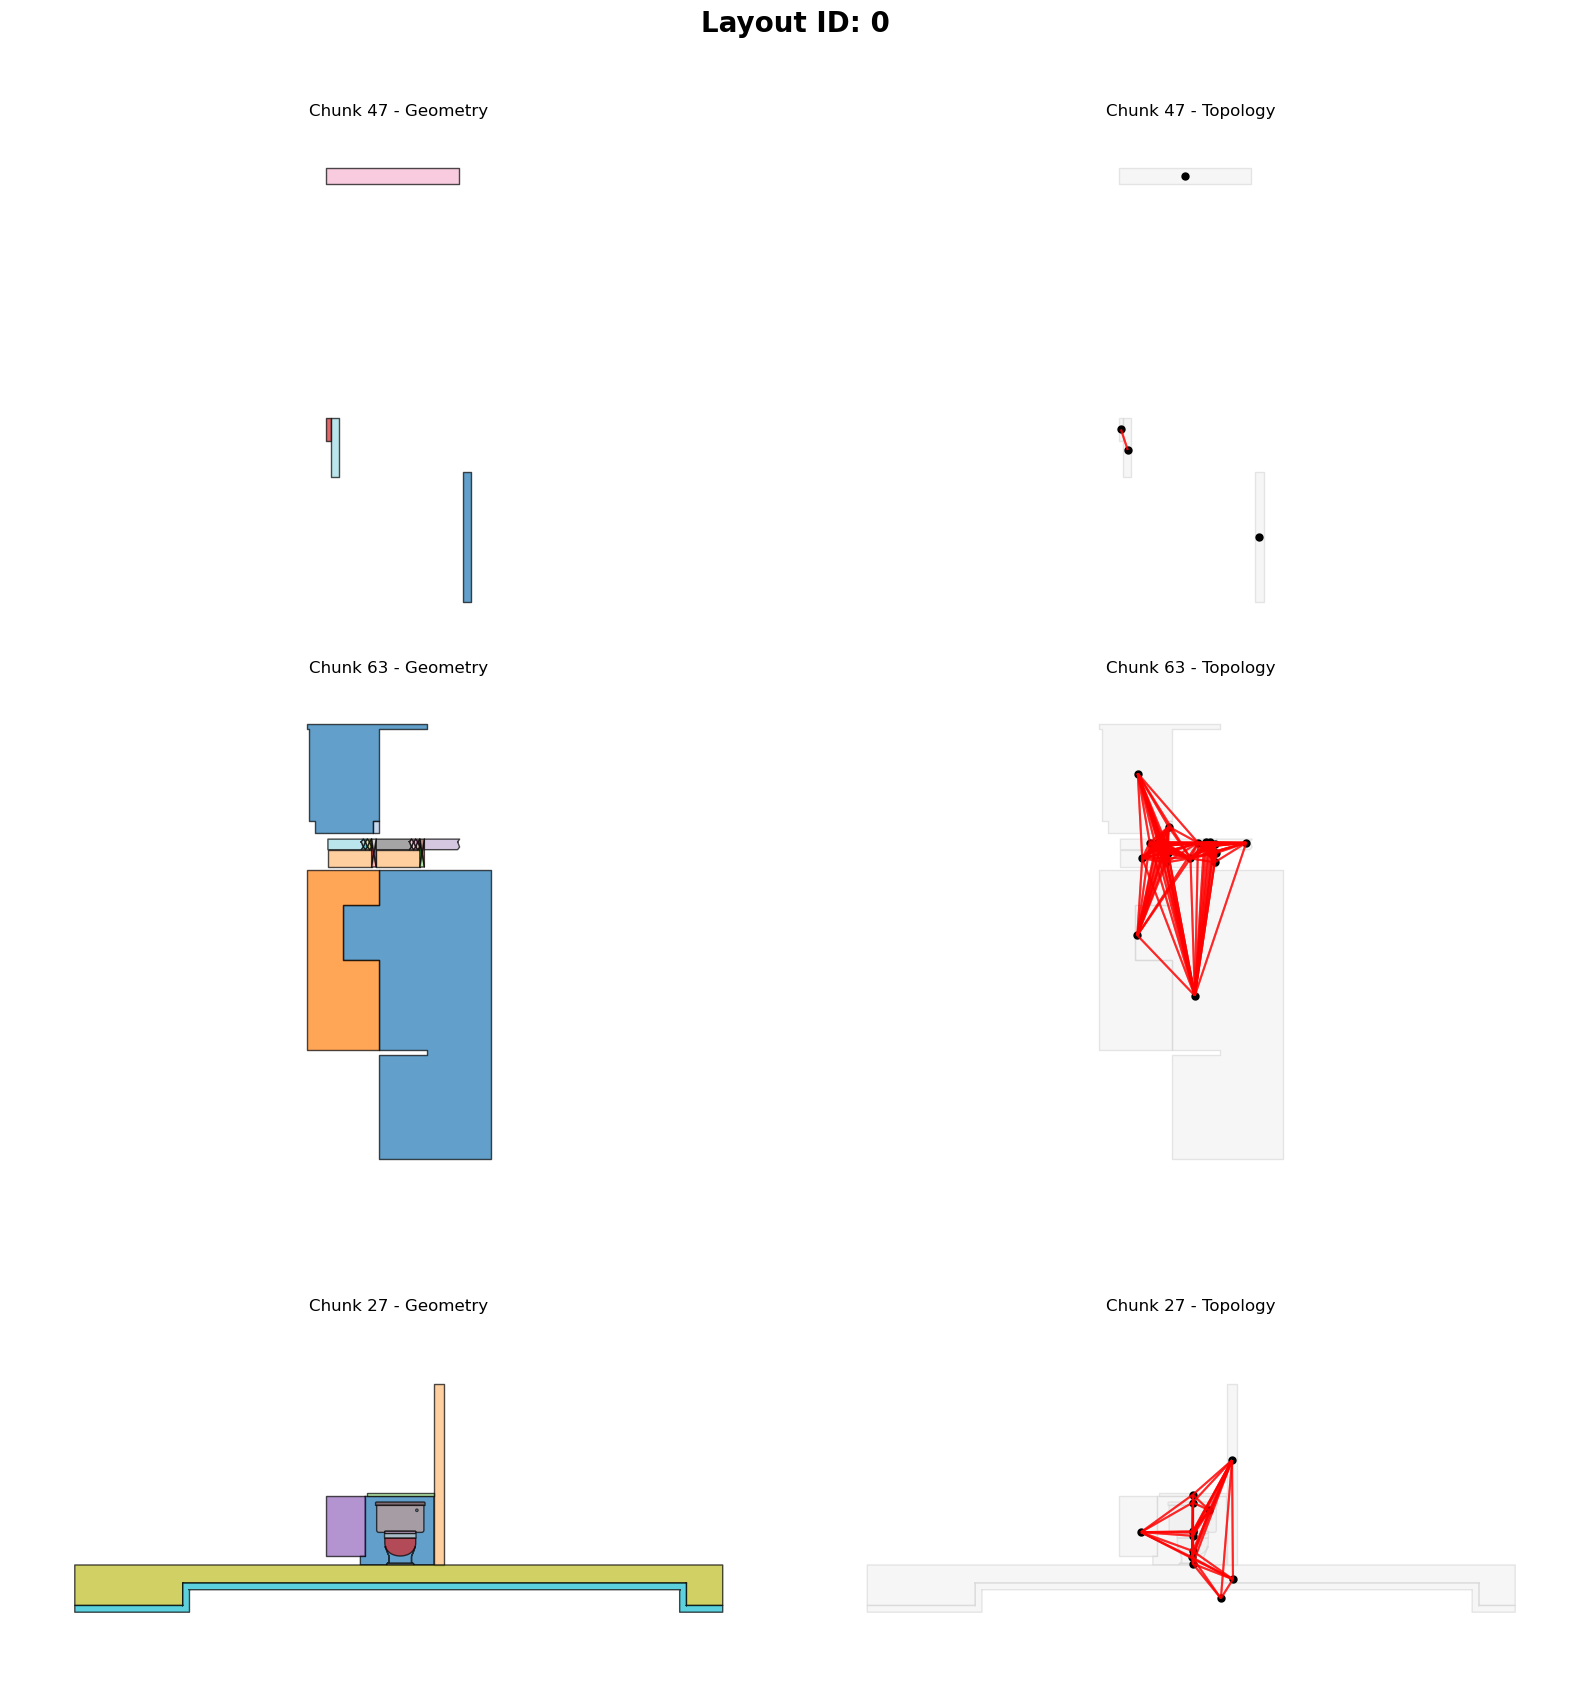


--- Visualizing Layout 1 (3 chunks) ---


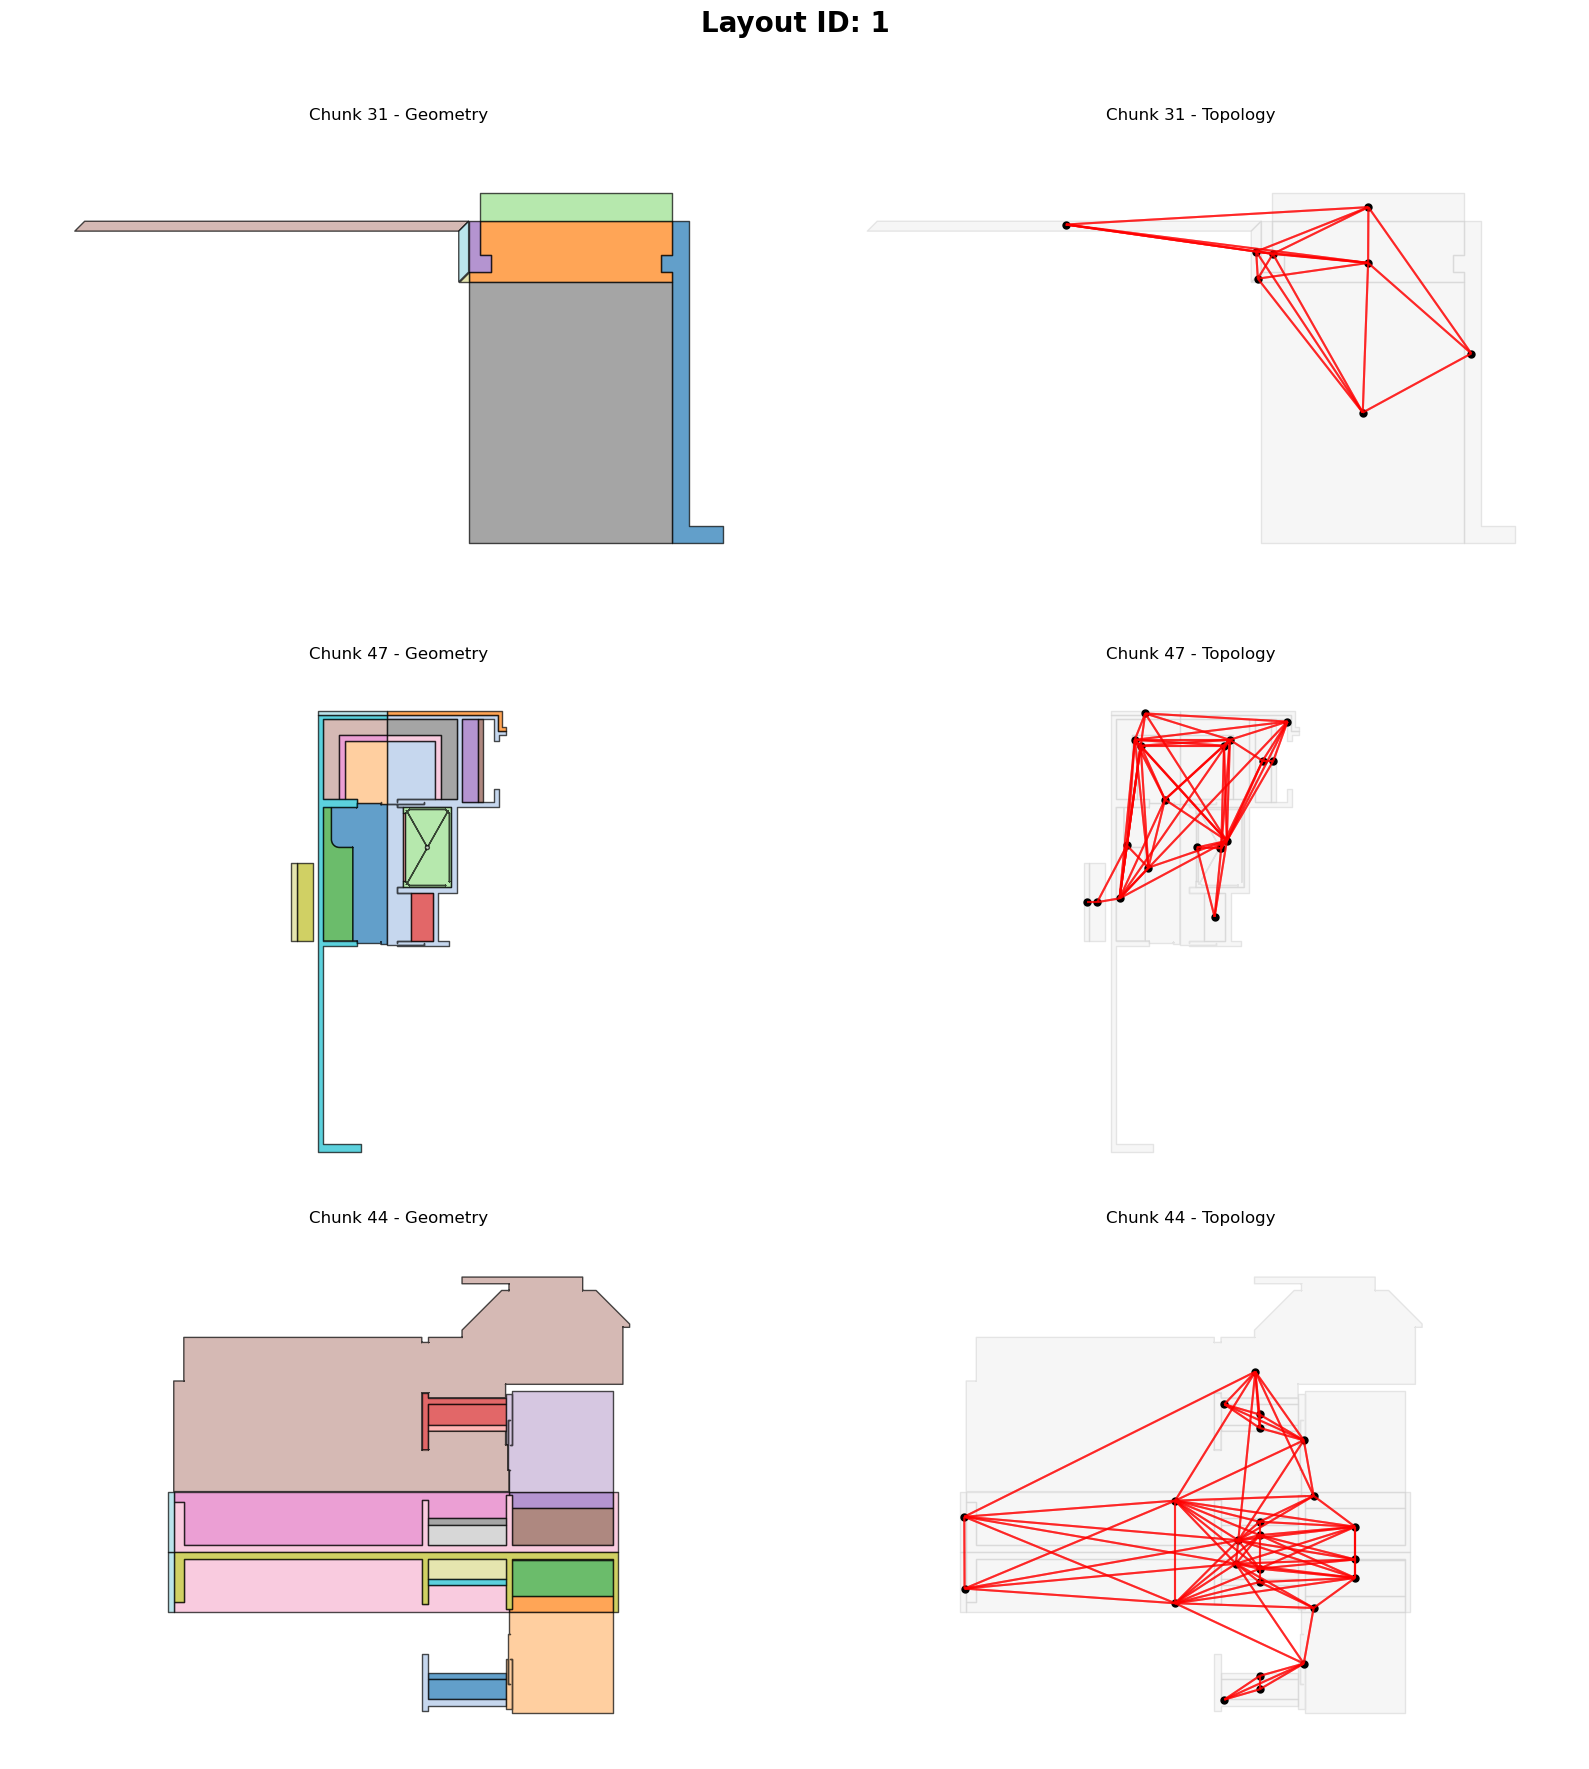

In [2]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection, LineCollection
from collections import defaultdict

# ==========================================
# 1. HELPER: GEOMETRY LOOKUP
# ==========================================
def build_geometry_lookup(geojson_path):
    """
    Creates a lookup: (layout_id, chunk_id) -> List of Polygon Coords
    Sorted by node_id.
    """
    print(f"[INFO] Indexing GeoJSON geometry from {geojson_path}...")
    
    grouped = {} 
    with open(geojson_path, 'r') as f:
        data = json.load(f)
        for feature in data['features']:
            props = feature['properties']
            lid = props['layout_id']
            cid = props['chunk_id']
            # Handle potential naming variations
            nid = props.get('node_id', props.get('chunk_node_id'))
            
            geom = feature['geometry']
            if geom and 'coordinates' in geom:
                key = (lid, cid)
                if key not in grouped: grouped[key] = []
                grouped[key].append((nid, geom['coordinates'][0]))
    
    # Sort by node_id and extract coords
    lookup = {}
    for key, items in grouped.items():
        items.sort(key=lambda x: x[0]) 
        lookup[key] = [item[1] for item in items]
    return lookup

def group_indices_by_layout(dataset):
    """
    Returns a dict: { layout_id: [dataset_index_1, dataset_index_2, ...] }
    """
    print("[INFO] Grouping dataset indices by Layout ID...")
    layout_map = defaultdict(list)
    for idx, data in enumerate(dataset):
        lid = data.layout_id.item() if torch.is_tensor(data.layout_id) else data.layout_id
        layout_map[lid].append(idx)
    return layout_map

# ==========================================
# 2. VISUALIZATION LOGIC
# ==========================================
def visualize_layouts(dataset, geojson_path, samples_per_layout=3):
    
    # 1. Prepare Data Maps
    geo_lookup = build_geometry_lookup(geojson_path)
    layout_indices = group_indices_by_layout(dataset)
    
    unique_layouts = sorted(layout_indices.keys())
    print(f"[INFO] Found {len(unique_layouts)} unique layouts: {unique_layouts}")

    # 2. Iterate over EACH Layout
    for lid in unique_layouts:
        available_indices = layout_indices[lid]
        
        # Determine how many to plot (don't crash if layout has fewer chunks than requested)
        n_samples = min(len(available_indices), samples_per_layout)
        
        # Pick random samples for this specific layout
        selected_indices = np.random.choice(available_indices, n_samples, replace=False)
        
        print(f"\n--- Visualizing Layout {lid} ({n_samples} chunks) ---")

        # Create a Figure for this Layout
        fig, axes = plt.subplots(n_samples, 2, figsize=(16, 6 * n_samples))
        if n_samples == 1: axes = [axes] # Handle single row case
        
        # Set Figure Title
        fig.suptitle(f"Layout ID: {lid}", fontsize=20, fontweight='bold', y=0.98)

        for row, idx in enumerate(selected_indices):
            data = dataset[idx]
            cid = data.chunk_id.item() if torch.is_tensor(data.chunk_id) else data.chunk_id
            
            # --- A. Retrieve & Process Geometry ---
            poly_coords_list = geo_lookup.get((lid, cid), [])
            
            polygons = []
            true_centroids = []
            all_coords = []
            
            for coords in poly_coords_list:
                all_coords.append(coords)
                polygons.append(MplPolygon(np.array(coords), closed=True))
                
                # Calculate Centroid
                pts = np.array(coords[:-1]) 
                if len(pts) > 0:
                    true_centroids.append(np.mean(pts, axis=0))
                else:
                    true_centroids.append([0,0])

            true_centroids = np.array(true_centroids)
            
            # --- B. Plot Left: Raw Geometry ---
            ax_geo = axes[row][0] if n_samples > 1 else axes[0]
            
            if polygons:
                # Color polygons distinctively
                colors = plt.cm.tab20(np.linspace(0, 1, len(polygons)))
                pc = PatchCollection(polygons, facecolor=colors, edgecolor='black', alpha=0.7)
                ax_geo.add_collection(pc)
                
                # Scaling
                all_pts = np.concatenate([np.array(p) for p in all_coords])
                min_x, min_y = all_pts.min(axis=0)
                max_x, max_y = all_pts.max(axis=0)
                pad = max(max_x-min_x, max_y-min_y) * 0.1
                ax_geo.set_xlim(min_x - pad, max_x + pad)
                ax_geo.set_ylim(min_y - pad, max_y + pad)
            
            ax_geo.set_title(f"Chunk {cid} - Geometry", fontsize=12)
            ax_geo.set_aspect('equal')
            ax_geo.axis('off')

            # --- C. Plot Right: Graph Overlay ---
            ax_graph = axes[row][1] if n_samples > 1 else axes[1]
            
            # 1. Draw Nodes
            if len(true_centroids) > 0:
                ax_graph.scatter(true_centroids[:, 0], true_centroids[:, 1], c='black', s=25, zorder=5)
                
                # 2. Draw Edges
                edge_index = data.edge_index.numpy()
                lines = []
                if edge_index.shape[1] > 0:
                    for e in range(edge_index.shape[1]):
                        u, v = edge_index[0, e], edge_index[1, e]
                        if u < len(true_centroids) and v < len(true_centroids):
                            lines.append([true_centroids[u], true_centroids[v]])
                
                if lines:
                    lc = LineCollection(lines, colors='red', linewidths=1.5, alpha=0.6, zorder=10)
                    ax_graph.add_collection(lc)

            # 3. Draw Ghost Background
            if polygons:
                pc_ghost = PatchCollection(polygons, facecolor='#eeeeee', edgecolor='#d0d0d0', alpha=0.5, zorder=0)
                ax_graph.add_collection(pc_ghost)

            # Sync Axis
            ax_graph.set_xlim(ax_geo.get_xlim())
            ax_graph.set_ylim(ax_geo.get_ylim())
            ax_graph.set_title(f"Chunk {cid} - Topology", fontsize=12)
            ax_graph.set_aspect('equal')
            ax_graph.axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust for suptitle
        plt.show()

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    GEOJSON_FILE = "chunked_data.geojson"
    ROOT_DIR = "./dataset_root"

    # 1. Load Dataset
    dataset = ArchitecturalGraphDataset(root=ROOT_DIR)
    
    # 2. Visualize per Layout
    # This will generate ONE window per Layout ID
    visualize_layouts(dataset, GEOJSON_FILE, samples_per_layout=3)

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, global_mean_pool, global_max_pool
from torch_geometric.loader import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import os

# ==========================================
# 1. SOTA MODEL: Residual GATv2
# ==========================================
class GAT(nn.Module):
    def __init__(self, in_channels, hidden_dim=256, embedding_dim=128, heads=4):
        super().__init__()
        torch.manual_seed(42)
        
        self.hidden_dim = hidden_dim
        
        # --- Layer 1: Input Projection ---
        # Multi-head attention: output size = hidden_dim * heads
        # We set concat=True, so we divide hidden_dim by heads to keep sizes consistent
        head_dim = hidden_dim // heads
        
        self.conv1 = GATv2Conv(in_channels, head_dim, heads=heads, concat=True, dropout=0.1)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        
        # --- Layer 2: Deep Feature Extraction (Residual) ---
        self.conv2 = GATv2Conv(hidden_dim, head_dim, heads=heads, concat=True, dropout=0.1)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        
        # --- Layer 3: Deep Feature Extraction (Residual) ---
        self.conv3 = GATv2Conv(hidden_dim, head_dim, heads=heads, concat=True, dropout=0.1)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        
        # --- Layer 4: Final Graph Conv ---
        self.conv4 = GATv2Conv(hidden_dim, head_dim, heads=heads, concat=True, dropout=0.1)
        self.bn4 = nn.BatchNorm1d(hidden_dim)

        # --- Projection Head (MLP) ---
        # Input is hidden_dim * 2 because we use Mean + Max pooling
        self.lin1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, embedding_dim)
        
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x, edge_index, batch):
        # --- Block 1 ---
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.gelu(x) # GELU is modern standard
        x = self.dropout(x)
        
        # --- Block 2 (Residual) ---
        identity = x
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.gelu(x)
        x = self.dropout(x)
        x = x + identity # Skip Connection
        
        # --- Block 3 (Residual) ---
        identity = x
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.gelu(x)
        x = self.dropout(x)
        x = x + identity # Skip Connection

        # --- Block 4 ---
        x = self.conv4(x, edge_index)
        x = self.bn4(x)
        x = F.gelu(x)

        # --- Aggregation (SOTA Strategy) ---
        # Concatenate Mean (Average structure) + Max (Distinctive features)
        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1) # Size: hidden*2
        
        # --- Projection Head ---
        x = self.lin1(x)
        x = F.gelu(x)
        x = self.lin2(x)
        
        # L2 Normalize for Cosine Similarity
        x = F.normalize(x, p=2, dim=1) 
        return x

# ==========================================
# 2. AUGMENTATION (No Change)
# ==========================================
def augment_batch(batch, noise_level=0.05, edge_drop_prob=0.1):
    batch_aug = batch.clone()
    if batch_aug.x is not None:
        noise = torch.randn_like(batch_aug.x) * noise_level
        batch_aug.x += noise
    if batch_aug.edge_index.numel() > 0:
        mask = torch.rand(batch_aug.edge_index.size(1)) > edge_drop_prob
        batch_aug.edge_index = batch_aug.edge_index[:, mask]
    return batch_aug

# ==========================================
# 3. UTILS
# ==========================================
def run_epoch(loader, model, criterion, optimizer, device, is_training=True):
    if is_training: model.train()
    else: model.eval()

    total_loss = 0.0
    count = 0

    with torch.set_grad_enabled(is_training):
        for anchor_batch in loader:
            anchor_batch = anchor_batch.to(device)
            positive_batch = augment_batch(anchor_batch).to(device)
            
            if is_training: optimizer.zero_grad()

            anchor_emb = model(anchor_batch.x, anchor_batch.edge_index, anchor_batch.batch)
            pos_emb = model(positive_batch.x, positive_batch.edge_index, positive_batch.batch)
            
            # Batch Hard Negative Mining (Simple Version: Roll)
            neg_emb = torch.roll(anchor_emb, shifts=1, dims=0)

            loss = criterion(anchor_emb, pos_emb, neg_emb)
            
            if is_training:
                loss.backward()
                optimizer.step()
            
            total_loss += loss.item()
            count += 1
            
    return total_loss / count if count > 0 else 0.0

# ==========================================
# 4. MAIN LOOP
# ==========================================
def train():
    ROOT_DIR = "./dataset_root"
    EPOCHS = 100
    BATCH_SIZE = 32 
    LEARNING_RATE = 0.0005 # Lower LR for deeper network
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    print(f"[INFO] Device: {DEVICE}")

    # 1. Load Data
    dataset = ArchitecturalGraphDataset(root=ROOT_DIR)
    dataset = dataset.shuffle()
    
    val_size = int(len(dataset) * 0.2)
    train_size = len(dataset) - val_size
    train_dataset = dataset[:train_size]
    val_dataset = dataset[train_size:]
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
    
    # 2. Setup SOTA Model
    model = GAT(
        in_channels=dataset.num_features, 
        hidden_dim=256,  # Wider
        embedding_dim=128 # Larger Embedding
    ).to(DEVICE)
    
    # Optimizer with Weight Decay (Regularization)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    
    # SOTA Scheduler: Cosine Annealing with Warm Restarts
    # This restarts the learning rate every 20 epochs to find better local minima
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2)
    
    criterion = nn.TripletMarginLoss(margin=0.5, p=2) # Tighter margin for finer distinctions

    print(f"[INFO] Architecture: Residual GATv2 (4 Layers, 256 Hidden)")
    
    best_val_loss = float('inf')

    for epoch in range(1, EPOCHS + 1):
        train_loss = run_epoch(train_loader, model, criterion, optimizer, DEVICE, is_training=True)
        
        if len(val_loader) > 0:
            val_loss = run_epoch(val_loader, model, criterion, optimizer, DEVICE, is_training=False)
        else:
            val_loss = 0.0
            
        # Step the scheduler
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        if epoch % 5 == 0:
            print(f"Epoch {epoch:03d} | LR: {current_lr:.6f} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        if val_loss < best_val_loss and len(val_loader) > 0:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "trained_model_sota.pth")

    print(f"\n[DONE] Best Val Loss: {best_val_loss:.4f}")
    print("[SUCCESS] Model saved to 'trained_model_sota.pth'")

if __name__ == "__main__":
    train()

[INFO] Device: cpu
[INFO] Architecture: Residual GATv2 (4 Layers, 256 Hidden)
Epoch 005 | LR: 0.000427 | Train: 0.0402 | Val: 0.0362
Epoch 010 | LR: 0.000250 | Train: 0.0294 | Val: 0.0321
Epoch 015 | LR: 0.000073 | Train: 0.0161 | Val: 0.0296
Epoch 020 | LR: 0.000500 | Train: 0.0263 | Val: 0.0333
Epoch 025 | LR: 0.000481 | Train: 0.0253 | Val: 0.0418
Epoch 030 | LR: 0.000427 | Train: 0.0361 | Val: 0.0232
Epoch 035 | LR: 0.000346 | Train: 0.0344 | Val: 0.0211
Epoch 040 | LR: 0.000250 | Train: 0.0388 | Val: 0.0273
Epoch 045 | LR: 0.000154 | Train: 0.0223 | Val: 0.0308
Epoch 050 | LR: 0.000073 | Train: 0.0175 | Val: 0.0231
Epoch 055 | LR: 0.000019 | Train: 0.0226 | Val: 0.0223
Epoch 060 | LR: 0.000500 | Train: 0.0266 | Val: 0.0314
Epoch 065 | LR: 0.000495 | Train: 0.0309 | Val: 0.0218
Epoch 070 | LR: 0.000481 | Train: 0.0140 | Val: 0.0244
Epoch 075 | LR: 0.000458 | Train: 0.0190 | Val: 0.0272
Epoch 080 | LR: 0.000427 | Train: 0.0173 | Val: 0.0261
Epoch 085 | LR: 0.000389 | Train: 0.0201 |

[INFO] Model weights loaded.
[INFO] Generating embeddings for dataset...
----------------------------------------


Enter Index (0-237), 'r' for random, 'q' to quit:  2


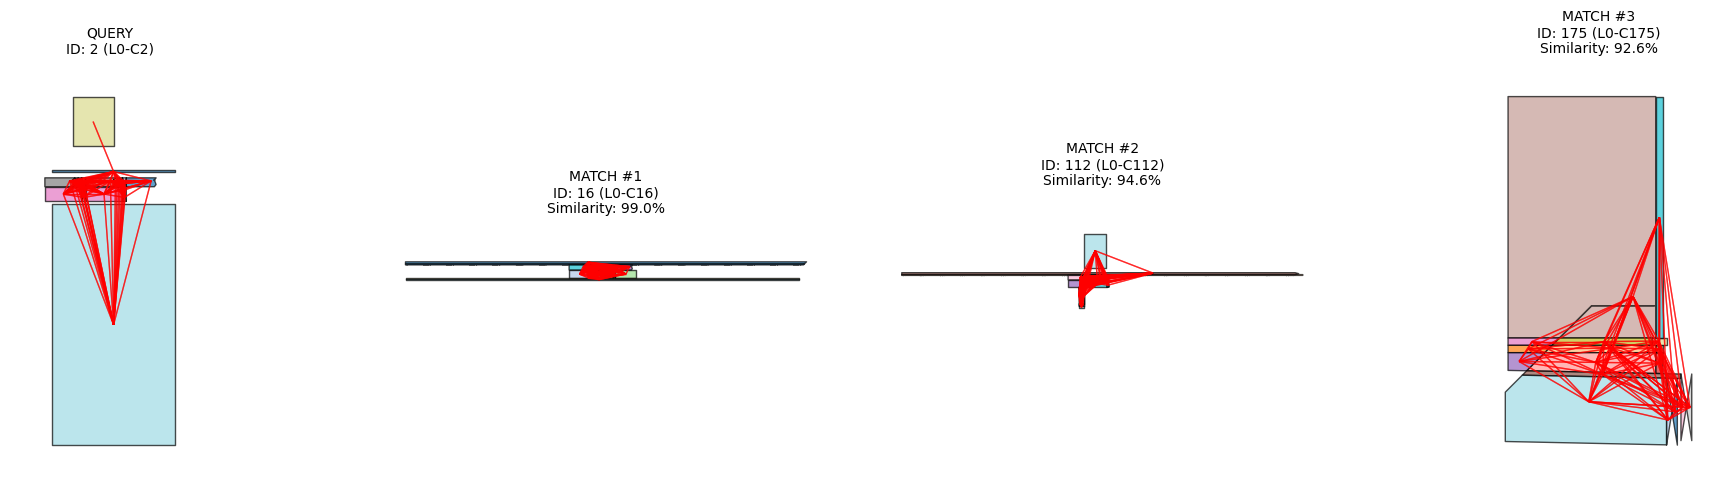

----------------------------------------


Enter Index (0-237), 'r' for random, 'q' to quit:  200


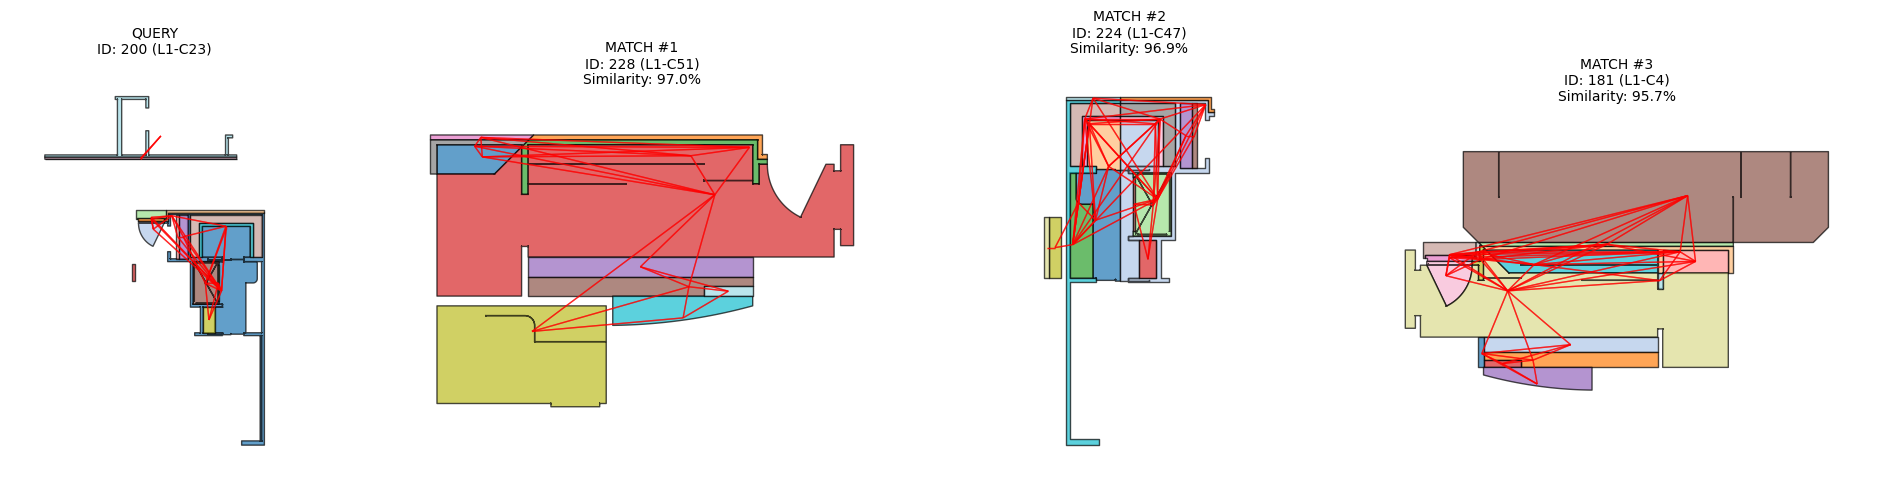

----------------------------------------


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.loader import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection, LineCollection
from sklearn.metrics.pairwise import cosine_similarity
import json
import os

# ==========================================
# 2. HELPER: GEOMETRY LOOKUP
# ==========================================
def build_geometry_lookup(geojson_path):
    """Indexes raw geometry from GeoJSON for visualization."""
    grouped = {} 
    with open(geojson_path, 'r') as f:
        data = json.load(f)
        for feature in data['features']:
            props = feature['properties']
            lid, cid = props['layout_id'], props['chunk_id']
            nid = props.get('node_id')
            if 'geometry' in feature and 'coordinates' in feature['geometry']:
                key = (lid, cid)
                if key not in grouped: grouped[key] = []
                # Store (node_id, coords)
                grouped[key].append((nid, feature['geometry']['coordinates'][0]))
    
    # Sort by node_id so indices match the graph node indices
    lookup = {}
    for key, items in grouped.items():
        items.sort(key=lambda x: x[0]) 
        lookup[key] = [item[1] for item in items]
    return lookup

# ==========================================
# 3. EMBEDDING GENERATOR
# ==========================================
def generate_embeddings(dataset, model, device):
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    model.eval()
    all_embeddings = []
    
    print("[INFO] Generating embeddings for dataset...")
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            emb = model(batch.x, batch.edge_index, batch.batch)
            all_embeddings.append(emb.cpu().numpy())
            
    return np.vstack(all_embeddings)

# ==========================================
# 4. VISUALIZATION
# ==========================================
def plot_chunk(ax, data, poly_coords_list, title, score=None):
    polygons = []
    true_centroids = []
    
    # 1. Build Polygons & Centroids
    for coords in poly_coords_list:
        polygons.append(MplPolygon(np.array(coords), closed=True))
        pts = np.array(coords[:-1]) 
        if len(pts) > 0: true_centroids.append(np.mean(pts, axis=0))
        else: true_centroids.append([0,0])
    true_centroids = np.array(true_centroids)
    
    # 2. Draw Polygons
    if polygons:
        colors = plt.cm.tab20(np.linspace(0, 1, len(polygons)))
        pc = PatchCollection(polygons, facecolor=colors, edgecolor='black', alpha=0.7)
        ax.add_collection(pc)
        
        # Auto-Scale
        all_pts = np.concatenate([np.array(p) for p in poly_coords_list])
        min_x, min_y = all_pts.min(axis=0)
        max_x, max_y = all_pts.max(axis=0)
        pad = max(max_x-min_x, max_y-min_y) * 0.1
        ax.set_xlim(min_x - pad, max_x + pad)
        ax.set_ylim(min_y - pad, max_y + pad)

    # 3. Draw Graph Edges
    if len(true_centroids) > 0 and data.edge_index.shape[1] > 0:
        edge_index = data.edge_index.numpy()
        lines = []
        for e in range(edge_index.shape[1]):
            u, v = edge_index[0, e], edge_index[1, e]
            if u < len(true_centroids) and v < len(true_centroids):
                lines.append([true_centroids[u], true_centroids[v]])
        lc = LineCollection(lines, colors='red', linewidths=1.0, alpha=0.6, zorder=10)
        ax.add_collection(lc)

    t_str = f"{title}"
    if score: t_str += f"\nSimilarity: {score:.1%}"
    ax.set_title(t_str, fontsize=10)
    ax.set_aspect('equal')
    ax.axis('off')

# ==========================================
# MAIN
# ==========================================
if __name__ == "__main__":
    ROOT_DIR = "./dataset_root"
    GEOJSON = "chunked_data.geojson"
    MODEL_PATH = "trained_model_sota.pth"
    
    # 1. Checks
    if not os.path.exists(MODEL_PATH):
        print(f"Error: {MODEL_PATH} not found. Please run the training script first.")
        exit()

    # 2. Load Data & Lookup
    dataset = ArchitecturalGraphDataset(root=ROOT_DIR)
    geo_lookup = build_geometry_lookup(GEOJSON)
    
    # 3. Load Model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GAT(
        in_channels=dataset.num_features, 
        hidden_dim=256, 
        embedding_dim=128
    ).to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    # model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print("[INFO] Model weights loaded.")

    # 4. Generate Vector DB
    embeddings = generate_embeddings(dataset, model, device)
    
    # 5. Search Loop
    while True:
        try:
            print("-" * 40)
            user_input = input(f"Enter Index (0-{len(dataset)-1}), 'r' for random, 'q' to quit: ")
            if user_input.lower() == 'q': break
            
            if user_input.lower() == 'r':
                query_idx = np.random.randint(0, len(dataset))
            else:
                query_idx = int(user_input)
                if query_idx >= len(dataset):
                    print("Index out of bounds.")
                    continue
        except ValueError: continue

        # --- Calculate Similarity ---
        query_vec = embeddings[query_idx].reshape(1, -1)
        # Cosine Similarity returns [[-1.0 to 1.0]]
        sim_scores = cosine_similarity(query_vec, embeddings)[0]
        
        # Get sorted indices (Highest score first)
        sorted_indices = np.argsort(sim_scores)[::-1]
        
        # --- Visualize ---
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        
        # 1. Plot Query
        q_data = dataset[query_idx]
        q_lid = q_data.layout_id.item() if torch.is_tensor(q_data.layout_id) else q_data.layout_id
        q_cid = q_data.chunk_id.item() if torch.is_tensor(q_data.chunk_id) else q_data.chunk_id
        
        q_geo = geo_lookup.get((q_lid, q_cid), [])
        plot_chunk(axes[0], q_data, q_geo, f"QUERY\nID: {query_idx} (L{q_lid}-C{q_cid})")
        
        # 2. Plot Matches
        count = 0
        for i in range(1, len(dataset)): # Start at 1 to skip self
            res_idx = sorted_indices[i]
            if res_idx == query_idx: continue
            
            score = sim_scores[res_idx]
            r_data = dataset[res_idx]
            
            # Retrieve IDs safely
            r_lid = r_data.layout_id.item() if torch.is_tensor(r_data.layout_id) else r_data.layout_id
            r_cid = r_data.chunk_id.item() if torch.is_tensor(r_data.chunk_id) else r_data.chunk_id
            
            r_geo = geo_lookup.get((r_lid, r_cid), [])
            
            plot_chunk(axes[count+1], r_data, r_geo, f"MATCH #{count+1}\nID: {res_idx} (L{r_lid}-C{r_cid})", score)
            
            count += 1
            if count >= 3: break
            
        plt.tight_layout()
        plt.show()